# Feature Analysis From Labeled Dataset JSONLs

This notebook analyzes structured data extracted from `dataset_labeled.jsonl` files across scenarios.

Included analyses:
- Data loading and quality checks
- Univariate distributions and summary statistics
- Correlation and covariance matrices
- Pairwise relationships (sampled matrix plots)
- PCA projections and explained variance

In [6]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("notebook")
np.set_printoptions(suppress=True, precision=4)
pd.set_option("display.max_columns", 120)

print("Libraries loaded.")

Libraries loaded.


In [10]:
# Discover labeled JSONLs and build analysis DataFrame
try:
    from MIREIA.config import Config
    scenarios_root = Path(Config.PATH_TO_SCENARIOS)
except Exception:
    scenarios_root = Path("scenarios")

source_jsonl_name = "dataset_labeled.jsonl"

# Integrated semantic feature names (order must match feature_vector_32 layout)
feature_names = [
    "num_objects",
    "bb_size_max",
    "bb_size_avg",
    "depth_min_norm",
    "depth_avg_norm",
    "size_change_max",
    "size_change_avg",
    "depth_change_max",
    "depth_change_avg",
    "bg_flow_x_norm",
    "bg_flow_y_norm",
    "left_threat_max",
    "left_threat_avg",
    "center_threat_max",
    "center_threat_avg",
    "right_threat_max",
    "right_threat_avg",
    "road_relative_size",
    "day_prob",
] + [f"climate_{i}" for i in range(1, 14)]

feature_vector_key = "feature_vector_32"
expected_feature_dim = len(feature_names)

if not scenarios_root.exists():
    raise FileNotFoundError(f"Scenarios root not found: {scenarios_root}")

scenario_dirs = [
    p for p in sorted(scenarios_root.iterdir())
    if p.is_dir() and p.name not in {"videos", "__pycache__"}
]

jsonl_paths = [p / source_jsonl_name for p in scenario_dirs if (p / source_jsonl_name).is_file()]
if not jsonl_paths:
    raise RuntimeError(f"No {source_jsonl_name} files found under {scenarios_root}")

rows = []
for path in jsonl_paths:
    scenario_name = path.parent.name
    with open(path, "r", encoding="utf-8") as f:
        for line_idx, line in enumerate(f, start=1):
            line = line.strip()
            if not line:
                continue
            try:
                rec = json.loads(line)
            except json.JSONDecodeError:
                continue

            env = rec.get("environment", {}) if isinstance(rec.get("environment", {}), dict) else {}
            ego = rec.get("ego", {}) if isinstance(rec.get("ego", {}), dict) else {}

            vec = rec.get(feature_vector_key)
            if isinstance(vec, (list, tuple)) and len(vec) == expected_feature_dim:
                feat = [float(v) for v in vec]
                has_feature = 1
            else:
                feat = [np.nan] * expected_feature_dim
                has_feature = 0

            row = {
                "scenario": scenario_name,
                "frame_id": rec.get("frame_id", np.nan),
                "ground_truth_risk": rec.get("ground_truth_risk", np.nan),
                "predicted_risk": rec.get("predicted_risk", np.nan),
                "true_ego_speed": rec.get("true_ego_speed", ego.get("speed", np.nan)),
                "day_night": env.get("day_night", rec.get("day_night", None)),
                "weather": env.get("weather", env.get("climate", rec.get("weather", None))),
                "has_feature_vector": has_feature,
            }
            for i, value in enumerate(feat):
                row[feature_names[i]] = value
            rows.append(row)

if not rows:
    raise RuntimeError("No valid records were loaded from labeled JSONLs.")

df = pd.DataFrame(rows)
for col in ["frame_id", "ground_truth_risk", "predicted_risk", "true_ego_speed"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

feature_cols = feature_names.copy()

print(f"Loaded records: {len(df):,}")
print(f"Scenarios with labeled data: {df['scenario'].nunique():,}")
print(f"Rows with valid {feature_vector_key}: {int(df['has_feature_vector'].sum()):,}")
print(f"Feature columns loaded: {len(feature_cols)}")

Loaded records: 230,400
Scenarios with labeled data: 64
Rows with valid feature_vector_32: 230,400
Feature columns loaded: 32


In [ ]:
# Feature order preview (already integrated in the loading cell above)
print("Feature columns (ordered):")
for i, name in enumerate(feature_cols, start=1):
    print(f"{i:02d}. {name}")

In [11]:
# Basic overview and quality checks

def _safe_nunique(series: pd.Series) -> int:
    try:
        return int(series.nunique(dropna=True))
    except TypeError:
        # Handle unhashable values (e.g., dict/list) by stringifying before counting
        return int(series.astype(str).nunique(dropna=True))

overview = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_pct": (df.isna().mean() * 100).round(2),
    "unique": df.apply(_safe_nunique),
})

print("DataFrame shape:", df.shape)
print("\nTop scenarios by record count:")
print(df["scenario"].value_counts().head(10))

print("\nMissingness overview (first 20 columns):")
display(overview.head(20))

print("\nNumeric summary:")
display(df[["ground_truth_risk", "predicted_risk", "true_ego_speed"] + feature_cols].describe().T.head(15))

display(df.head(5))

DataFrame shape: (230400, 40)

Top scenarios by record count:
scenario
01A_ClearNoon_Town01_HighVol     3600
01B_ClearNoon_Town01_LowVol      3600
01C_ClearNoon_Town02_HighVol     3600
01D_ClearNoon_Town02_LowVol      3600
02A_CloudyNoon_Town03_HighVol    3600
02B_CloudyNoon_Town03_LowVol     3600
02C_CloudyNoon_Town04_HighVol    3600
02D_CloudyNoon_Town04_LowVol     3600
03A_WetNoon_Town05_HighVol       3600
03B_WetNoon_Town05_LowVol        3600
Name: count, dtype: int64

Missingness overview (first 20 columns):


,dtype,missing_pct,unique
scenario,str,0.0,64
frame_id,int64,0.0,3600
ground_truth_risk,float64,0.0,203039
predicted_risk,float64,100.0,0
true_ego_speed,float64,0.0,57354
day_night,object,100.0,0
weather,object,0.0,22
has_feature_vector,int64,0.0,1
num_objects,float64,0.0,15
bb_size_max,float64,0.0,168914



Numeric summary:


,count,mean,std,min,25%,50%,75%,max
ground_truth_risk,230400.0,3.239256,3.175288,0.035715,1.598596e+00,2.259251,3.637066,48.678699
predicted_risk,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
true_ego_speed,230400.0,4.911449,6.439359,0.000000,1.435445e-09,2.383063,8.022140,24.314718
num_objects,230400.0,2.236836,2.157123,0.000000,1.000000e+00,2.000000,4.000000,14.000000
bb_size_max,230400.0,0.090928,0.097082,0.000000,0.000000e+00,0.061228,0.147003,0.686248
bb_size_avg,230400.0,0.061075,0.063309,0.000000,0.000000e+00,0.044222,0.092070,0.686248
depth_min_norm,230400.0,0.269539,0.436476,0.000015,5.404375e-03,0.009045,1.000000,1.000000
depth_avg_norm,230400.0,0.009416,0.009249,0.000000,0.000000e+00,0.008963,0.013902,1.000000
size_change_max,230400.0,0.762922,0.460416,0.000000,0.000000e+00,1.003899,1.032633,3.946243
size_change_avg,230400.0,0.744100,0.446798,0.000000,0.000000e+00,0.996474,1.010031,3.058724


,scenario,frame_id,ground_truth_risk,predicted_risk,true_ego_speed,day_night,weather,has_feature_vector,num_objects,bb_size_max,bb_size_avg,depth_min_norm,depth_avg_norm,size_change_max,size_change_avg,depth_change_max,depth_change_avg,bg_flow_x_norm,bg_flow_y_norm,left_threat_max,left_threat_avg,center_threat_max,center_threat_avg,right_threat_max,right_threat_avg,road_relative_size,day_prob,climate_1,climate_2,climate_3,climate_4,climate_5,climate_6,climate_7,climate_8,climate_9,climate_10,climate_11,climate_12,climate_13
0,01A_ClearNoon_Town01_HighVol,0,4.682484,NaN,7.874935,None,ClearNoon,1,2.0,0.060099,0.043675,0.003241,0.005667,1.000001,1.000000,0.999999,0.999998,0.000000,0.000000,0.0,0.0,3.085033,2.160293,0.0,0.0,0.137772,0.996484,0.989570,0.000260,0.000036,0.000014,0.000186,0.000005,0.000087,0.000437,0.000023,0.009227,0.000156,0.0,0.0
1,01A_ClearNoon_Town01_HighVol,1,4.697520,NaN,7.791110,None,ClearNoon,1,2.0,0.058856,0.043304,0.004027,0.006495,1.037288,0.998162,1.242200,1.174860,0.000185,0.000014,0.0,0.0,2.579535,1.827205,0.0,0.0,0.148300,0.997826,0.986546,0.000250,0.000029,0.000011,0.000145,0.000004,0.000079,0.000355,0.000019,0.012412,0.000150,0.0,0.0
2,01A_ClearNoon_Town01_HighVol,2,4.731431,NaN,7.794961,None,ClearNoon,1,2.0,0.063058,0.046356,0.003742,0.006614,1.159142,1.141613,1.053768,1.010443,-0.000016,-0.000011,0.0,0.0,3.005979,2.117209,0.0,0.0,0.161743,0.997953,0.969716,0.000400,0.000036,0.000016,0.000185,0.000005,0.000115,0.000476,0.000026,0.028807,0.000217,0.0,0.0
3,01A_ClearNoon_Town01_HighVol,3,4.766882,NaN,7.815786,None,ClearNoon,1,2.0,0.067992,0.049425,0.003582,0.006443,1.110168,1.074126,0.982283,0.969736,-0.000027,0.000096,0.0,0.0,2.899189,2.050394,0.0,0.0,0.167404,0.998099,0.975810,0.000333,0.000030,0.000013,0.000154,0.000004,0.000090,0.000400,0.000022,0.022970,0.000173,0.0,0.0
4,01A_ClearNoon_Town01_HighVol,4,4.817879,NaN,7.911495,None,ClearNoon,1,2.0,0.072558,0.052257,0.003841,0.007321,1.103613,1.079633,1.157721,1.117288,-0.000044,0.000139,0.0,0.0,2.749747,1.889194,0.0,0.0,0.178513,0.997122,0.967602,0.000475,0.000044,0.000020,0.000217,0.000007,0.000134,0.000568,0.000033,0.030649,0.000252,0.0,0.0


## Univariate Analysis
Distribution-level analysis for target, speed, and high-variance feature dimensions.

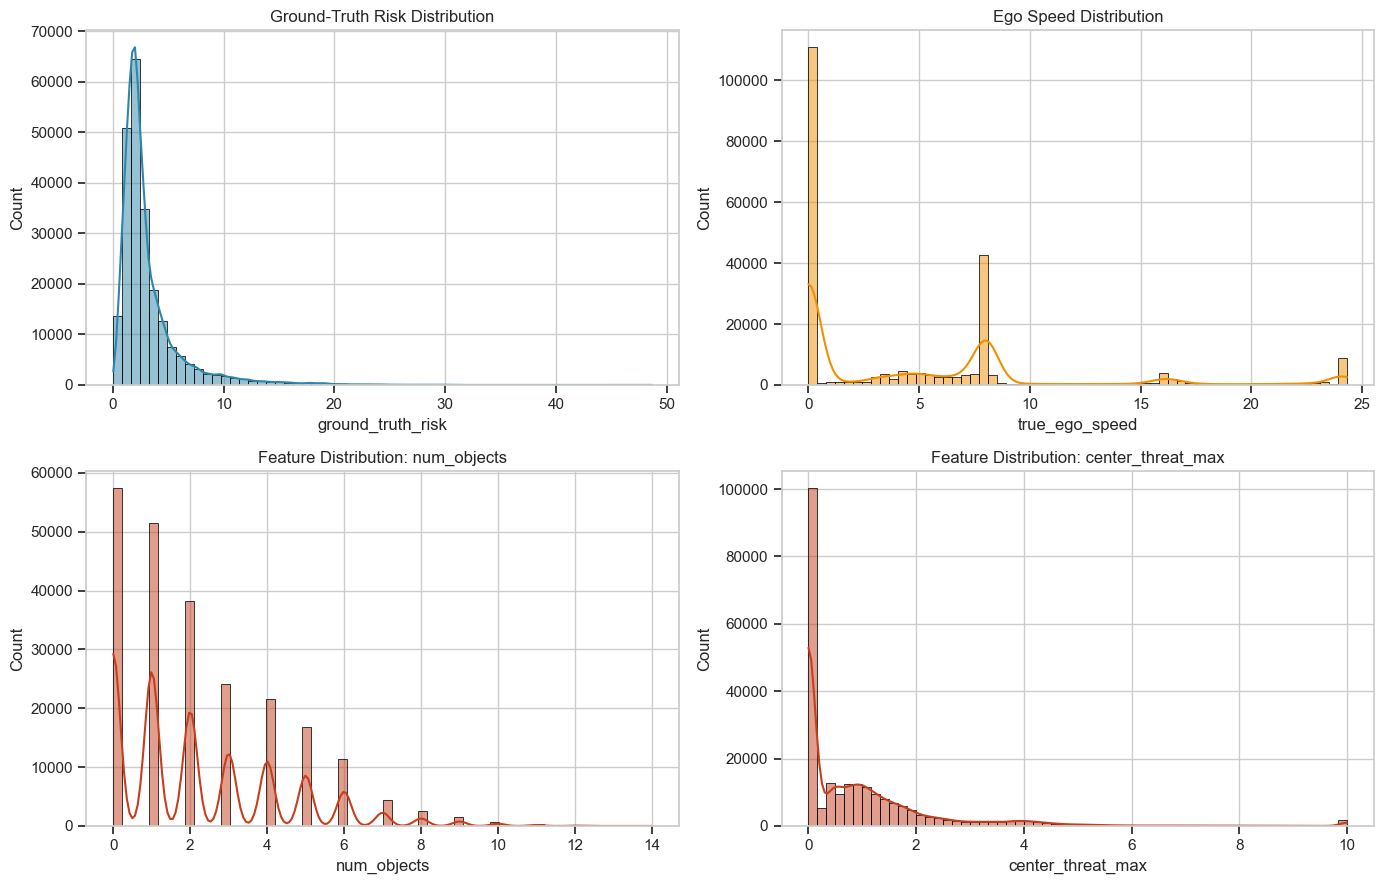

Top 10 most variable feature dimensions:
num_objects          4.653178
center_threat_max    2.240908
center_threat_avg    1.505809
left_threat_max      0.981935
right_threat_max     0.541374
left_threat_avg      0.497578
right_threat_avg     0.397396
depth_change_max     0.212142
size_change_max      0.211983
size_change_avg      0.199629
dtype: float64


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

sns.histplot(df["ground_truth_risk"], kde=True, bins=60, ax=axes[0, 0], color="#2E86AB")
axes[0, 0].set_title("Ground-Truth Risk Distribution")

sns.histplot(df["true_ego_speed"], kde=True, bins=60, ax=axes[0, 1], color="#F18F01")
axes[0, 1].set_title("Ego Speed Distribution")

# Highest-variance feature dimensions for quick inspection
feature_var = df[feature_cols].var(numeric_only=True).sort_values(ascending=False)
top_feat = feature_var.head(2).index.tolist()

for k, feat in enumerate(top_feat):
    r = 1
    c = k
    sns.histplot(df[feat], kde=True, bins=60, ax=axes[r, c], color="#C73E1D")
    axes[r, c].set_title(f"Feature Distribution: {feat}")

plt.tight_layout()
plt.show()

print("Top 10 most variable feature dimensions:")
print(feature_var.head(10))

## Matrix Analyses
Correlation and covariance structures for the feature vector and target variables.

Top correlated features with ground_truth_risk:


,pearson,spearman
climate_5,0.331719,0.315668
climate_1,-0.158161,-0.171020
climate_7,0.132704,0.106563
climate_10,-0.109876,-0.127781
num_objects,-0.109114,-0.047785
right_threat_max,-0.106038,-0.096814
climate_11,-0.104824,-0.084006
right_threat_avg,-0.103319,-0.096661
climate_6,0.100265,0.047704
climate_3,-0.085419,-0.011027


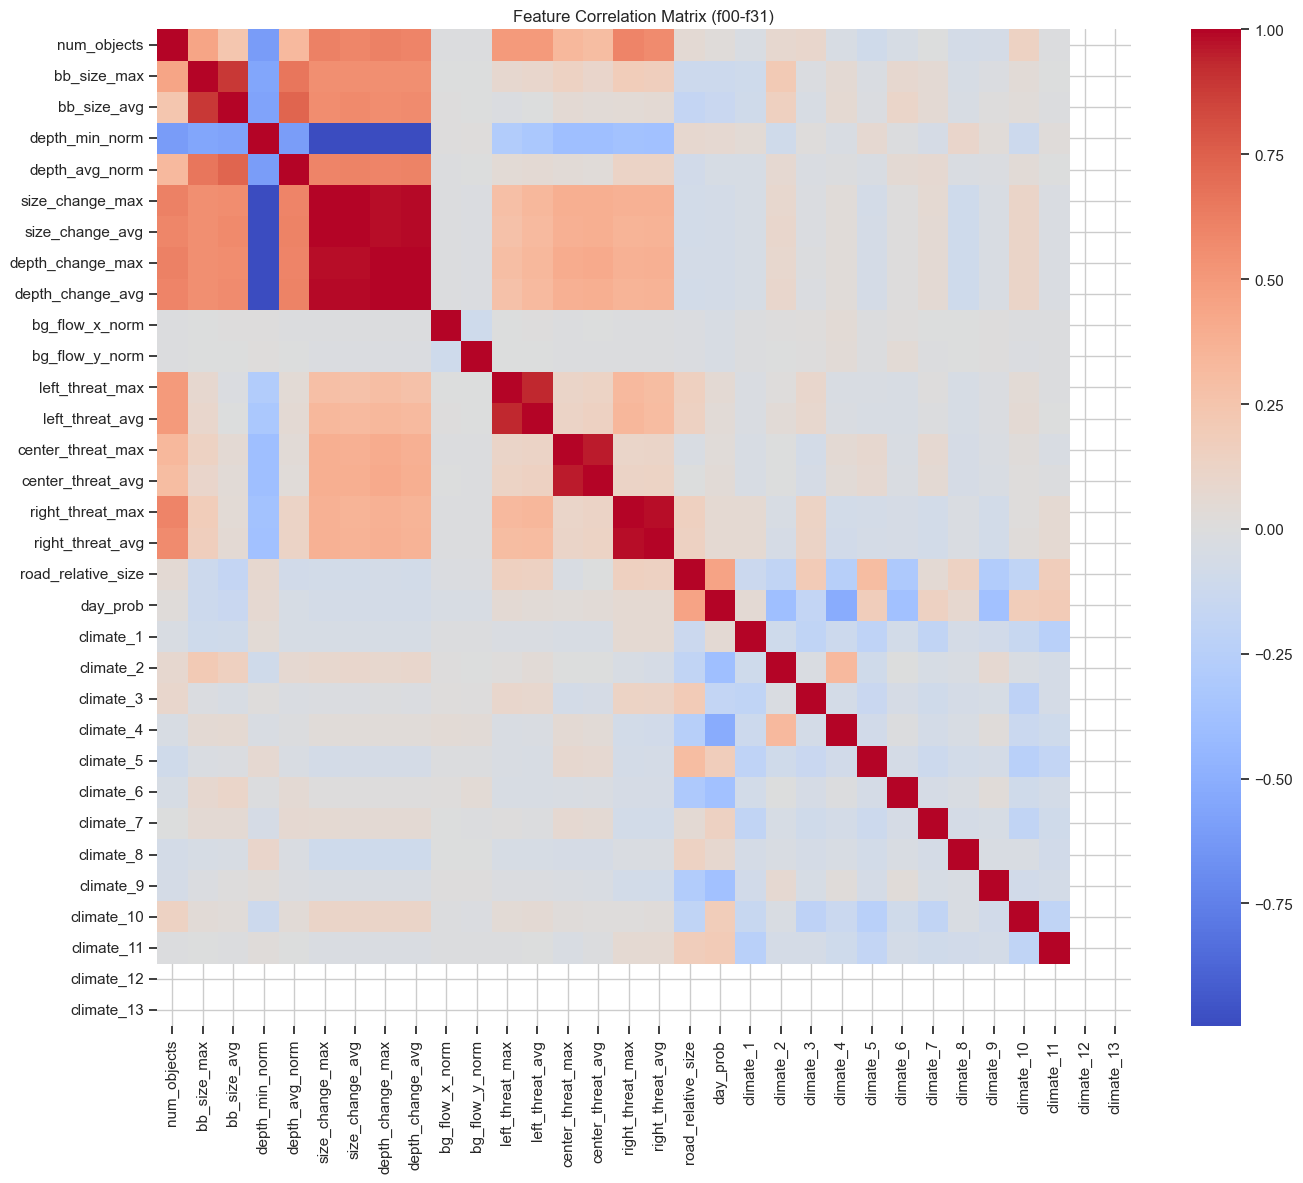

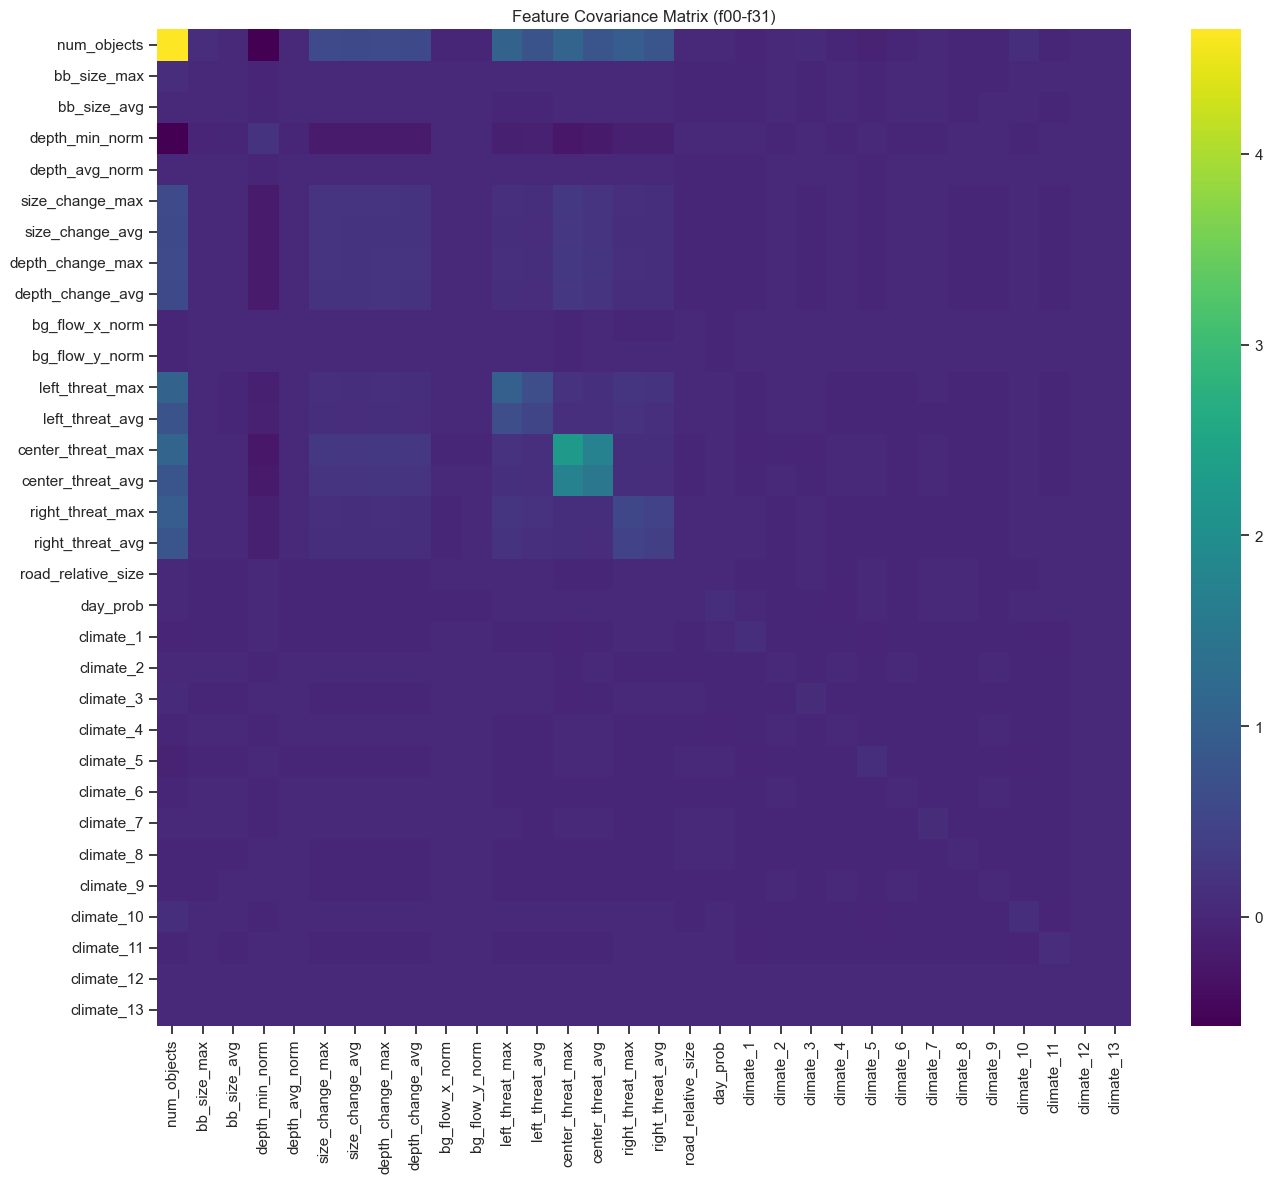

In [13]:
# Correlation with target (Pearson and Spearman)
pearson_target = df[feature_cols + ["ground_truth_risk"]].corr(method="pearson")["ground_truth_risk"].drop("ground_truth_risk")
spearman_target = df[feature_cols + ["ground_truth_risk"]].corr(method="spearman")["ground_truth_risk"].drop("ground_truth_risk")

corr_table = pd.DataFrame({
    "pearson": pearson_target,
    "spearman": spearman_target,
}).sort_values("pearson", key=lambda s: s.abs(), ascending=False)

print("Top correlated features with ground_truth_risk:")
display(corr_table.head(15))

# Full feature correlation matrix
corr_feat = df[feature_cols].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr_feat, cmap="coolwarm", center=0.0)
plt.title("Feature Correlation Matrix (f00-f31)")
plt.tight_layout()
plt.show()

# Covariance matrix
cov_feat = df[feature_cols].cov()
plt.figure(figsize=(14, 12))
sns.heatmap(cov_feat, cmap="viridis")
plt.title("Feature Covariance Matrix (f00-f31)")
plt.tight_layout()
plt.show()

## Pairwise Matrix Plot (Sampled)
A compact pairwise view on risk plus top correlated feature dimensions.

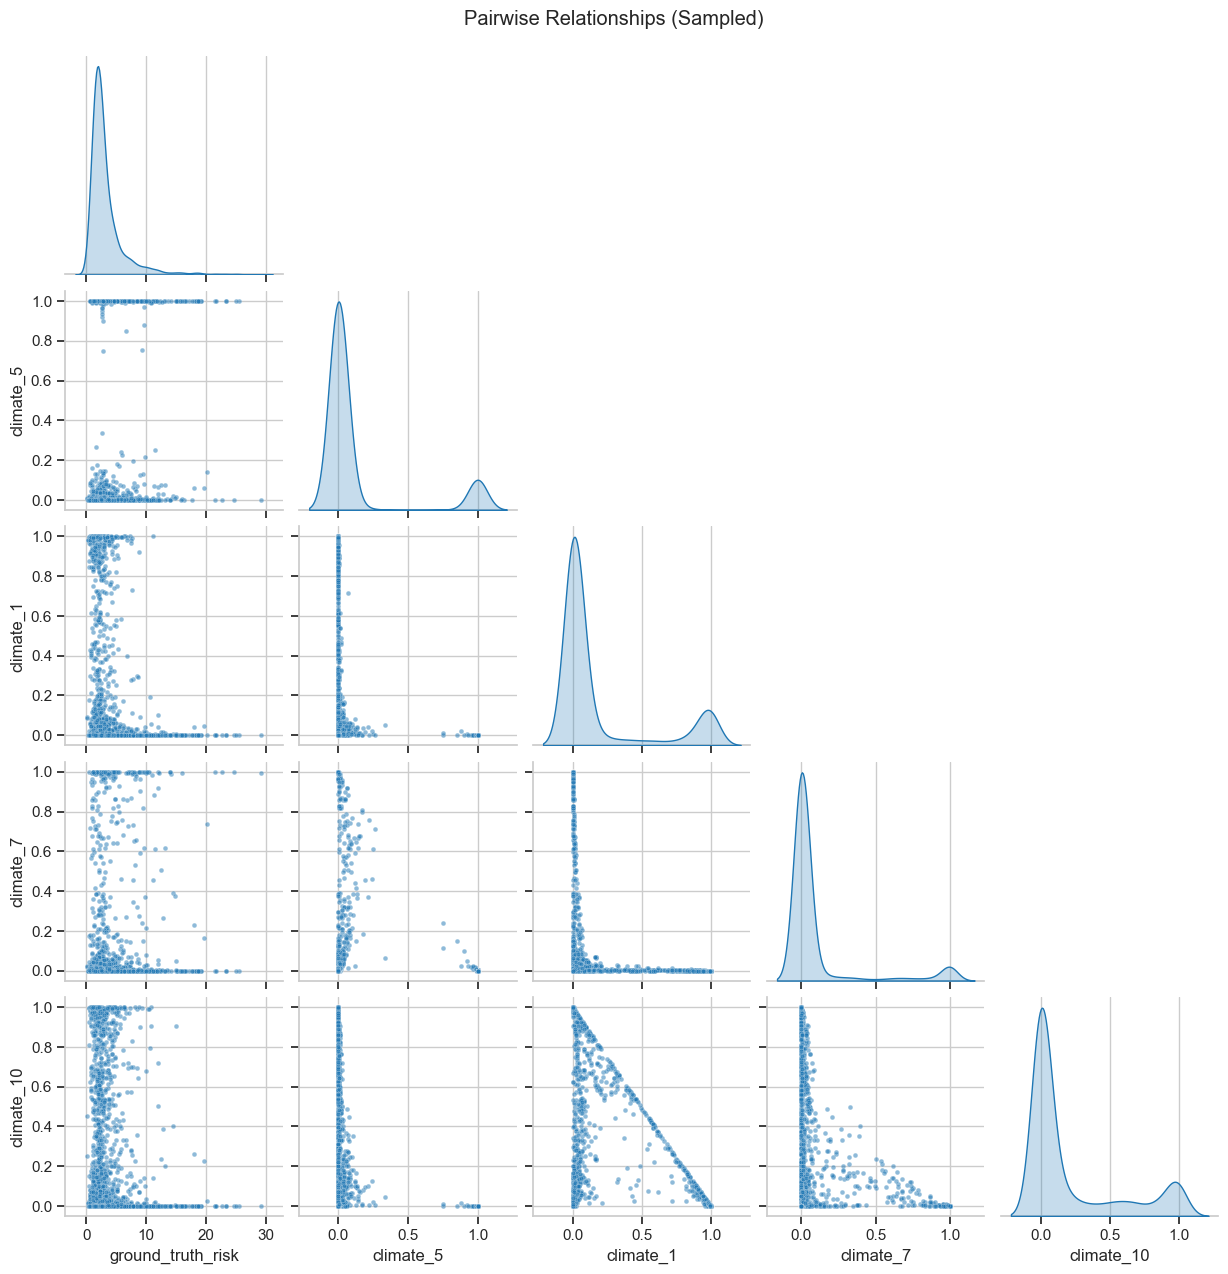

In [14]:
top_pair_features = corr_table.head(4).index.tolist()
pair_cols = ["ground_truth_risk"] + top_pair_features

pair_df = df[pair_cols].copy().dropna()
max_pair_rows = 2500
if len(pair_df) > max_pair_rows:
    pair_df = pair_df.sample(max_pair_rows, random_state=42)

sns.pairplot(pair_df, corner=True, diag_kind="kde", plot_kws={"s": 12, "alpha": 0.5})
plt.suptitle("Pairwise Relationships (Sampled)", y=1.02)
plt.show()

## PCA Analysis
2D and 3D PCA projections on standardized feature vectors, first colored by target risk and then by loaded town label (e.g., TOWN01).

Explained variance ratio (2D): [0.254  0.0996]
Cumulative explained variance (2D): 0.3535887487276035


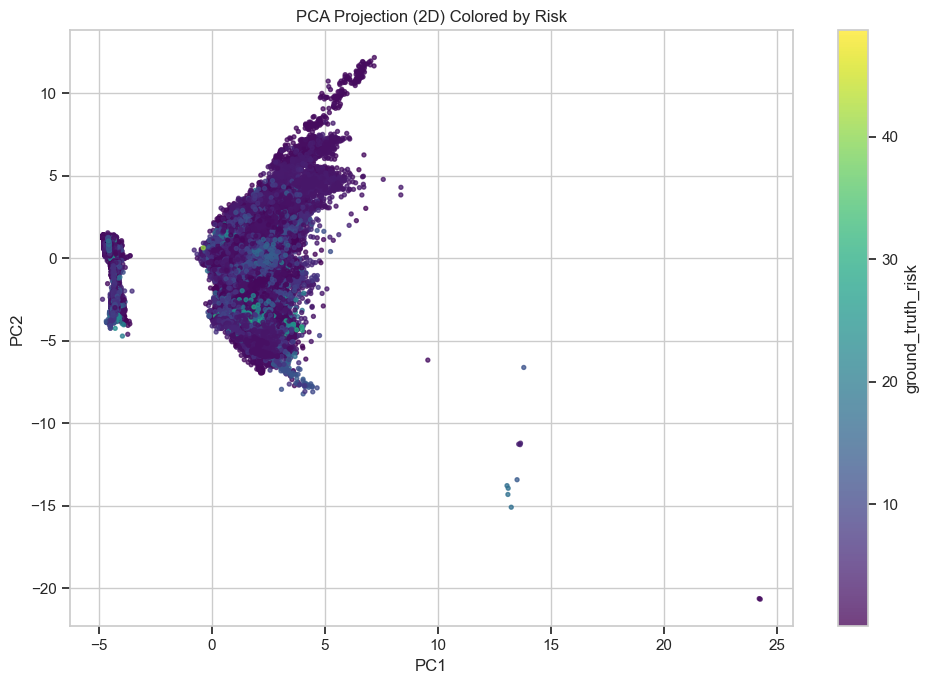

Explained variance ratio (3D): [0.254  0.0996 0.0701]
Cumulative explained variance (3D): 0.4236961514020524


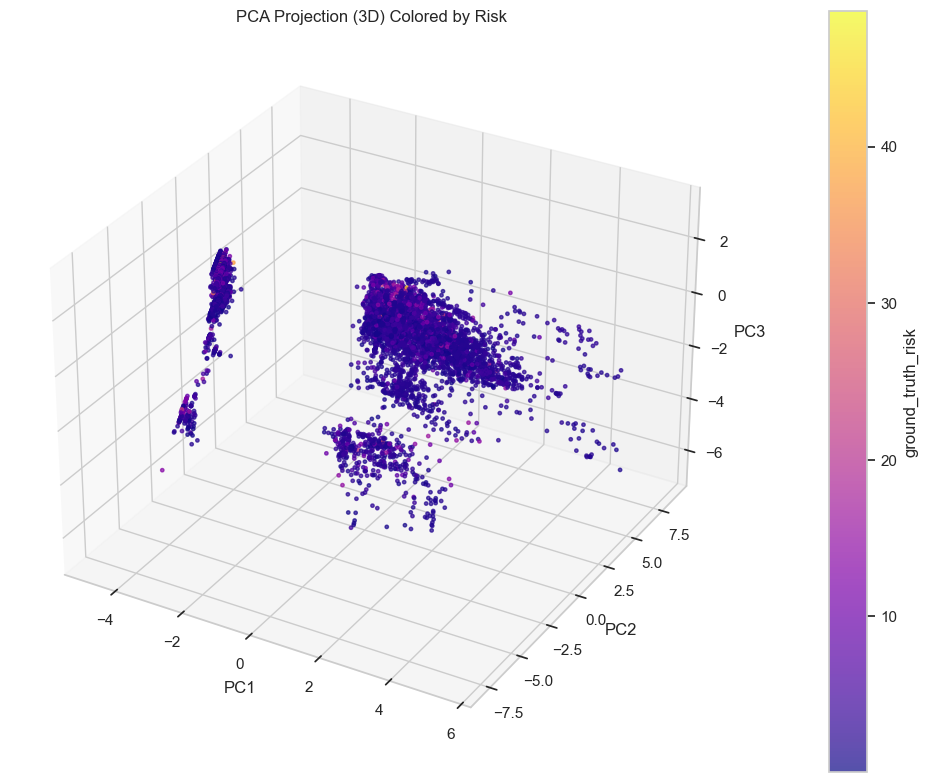

Towns found: ['TOWN01', 'TOWN02', 'TOWN03', 'TOWN04', 'TOWN05', 'TOWN10']


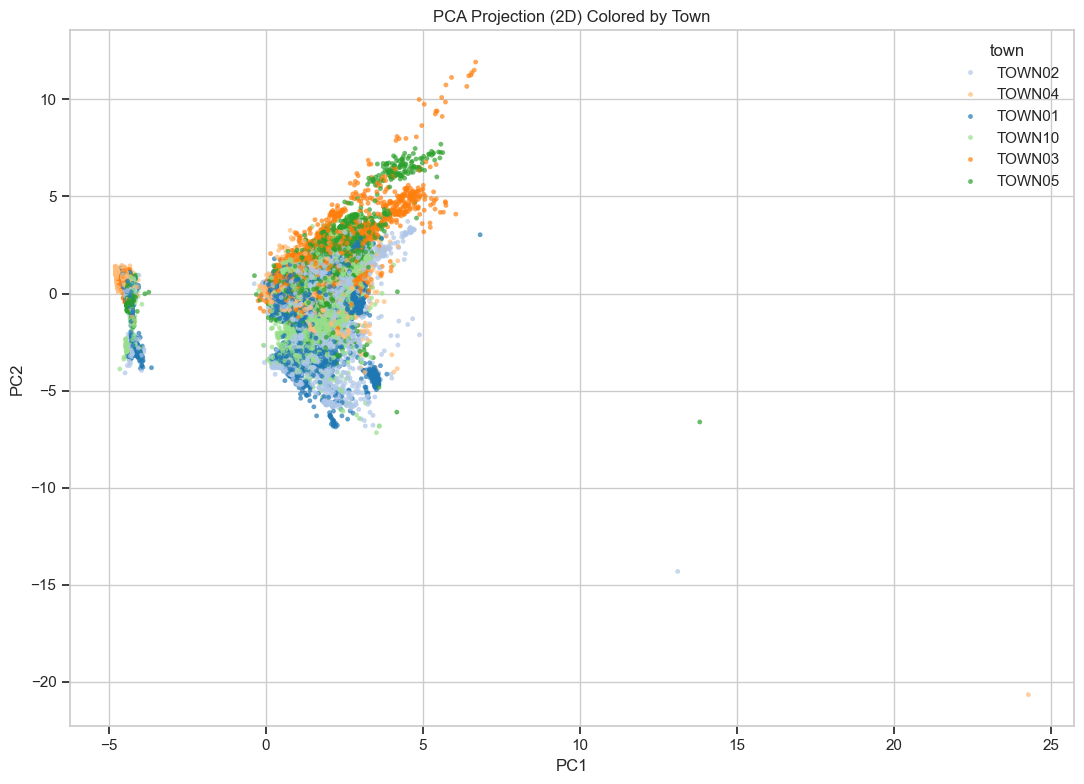

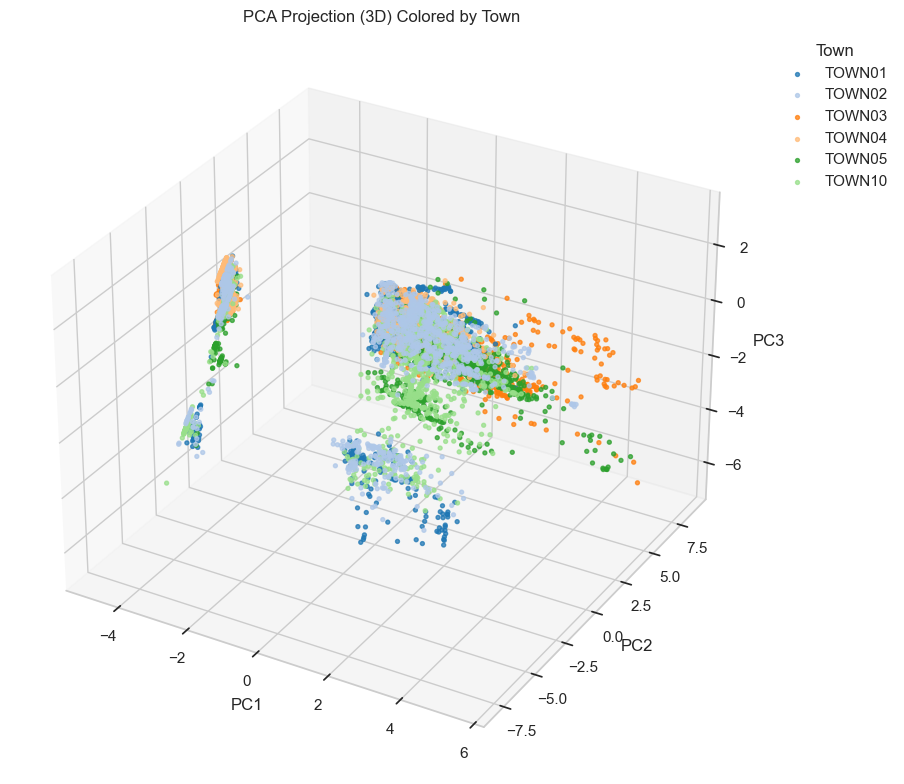

In [16]:
# Prepare matrix
X = df[feature_cols].copy()
y = pd.to_numeric(df["ground_truth_risk"], errors="coerce")

# Keep rows where target exists; impute feature NaNs
valid_target = y.notna()
X = X.loc[valid_target]
y = y.loc[valid_target]

# Extract compact town labels (e.g., TOWN01) from scenario names for later coloring
scenario_for_pca = df.loc[valid_target, "scenario"].astype(str)
town_labels = (
    scenario_for_pca
    .str.extract(r"(Town\d+)", expand=False)
    .str.upper()
    .fillna("UNKNOWN")
)

imputer = SimpleImputer(strategy="median")
X_imp = imputer.fit_transform(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imp)

# 2D PCA (colored by risk)
pca2 = PCA(n_components=2, random_state=42)
X_pca2 = pca2.fit_transform(X_scaled)

print("Explained variance ratio (2D):", np.round(pca2.explained_variance_ratio_, 4))
print("Cumulative explained variance (2D):", float(np.sum(pca2.explained_variance_ratio_)))

plt.figure(figsize=(10, 7))
sc = plt.scatter(
    X_pca2[:, 0],
    X_pca2[:, 1],
    c=y.values,
    cmap="viridis",
    s=8,
    alpha=0.75,
)
plt.colorbar(sc, label="ground_truth_risk")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection (2D) Colored by Risk")
plt.tight_layout()
plt.show()

# 3D PCA (sampled for readability, colored by risk)
pca3 = PCA(n_components=3, random_state=42)
X_pca3 = pca3.fit_transform(X_scaled)
print("Explained variance ratio (3D):", np.round(pca3.explained_variance_ratio_, 4))
print("Cumulative explained variance (3D):", float(np.sum(pca3.explained_variance_ratio_)))

max_points_3d = 6000
if len(X_pca3) > max_points_3d:
    rng = np.random.default_rng(42)
    idx = rng.choice(len(X_pca3), size=max_points_3d, replace=False)
else:
    idx = np.arange(len(X_pca3))

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")
pts = ax.scatter(
    X_pca3[idx, 0],
    X_pca3[idx, 1],
    X_pca3[idx, 2],
    c=y.values[idx],
    cmap="plasma",
    s=6,
    alpha=0.7,
)
fig.colorbar(pts, ax=ax, pad=0.1, label="ground_truth_risk")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("PCA Projection (3D) Colored by Risk")
plt.tight_layout()
plt.show()

# Same PCA plots colored by town label only (e.g., TOWN01)
town_values = town_labels.values
town_unique = sorted(pd.unique(town_values))
print("Towns found:", town_unique)

# 2D PCA colored by town
plot_df_town_2d = pd.DataFrame({
    "PC1": X_pca2[:, 0],
    "PC2": X_pca2[:, 1],
    "town": town_values,
})

max_points_2d_town = 30000
if len(plot_df_town_2d) > max_points_2d_town:
    plot_df_town_2d = plot_df_town_2d.sample(max_points_2d_town, random_state=42)

palette = dict(zip(town_unique, sns.color_palette("tab20", n_colors=len(town_unique))))

plt.figure(figsize=(11, 8))
sns.scatterplot(
    data=plot_df_town_2d,
    x="PC1",
    y="PC2",
    hue="town",
    palette=palette,
    s=12,
    alpha=0.7,
    linewidth=0,
)
plt.title("PCA Projection (2D) Colored by Town")
plt.tight_layout()
plt.show()

# 3D PCA colored by town (use same sampled indices as risk plot for comparability)
town_sample = town_values[idx]
colors = sns.color_palette("tab20", n_colors=len(town_unique))
town_color_map = dict(zip(town_unique, colors))

fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection="3d")
for town in town_unique:
    mask = town_sample == town
    if not np.any(mask):
        continue
    ax.scatter(
        X_pca3[idx, 0][mask],
        X_pca3[idx, 1][mask],
        X_pca3[idx, 2][mask],
        color=town_color_map[town],
        label=town,
        s=8,
        alpha=0.75,
    )

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("PCA Projection (3D) Colored by Town")
ax.legend(title="Town", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

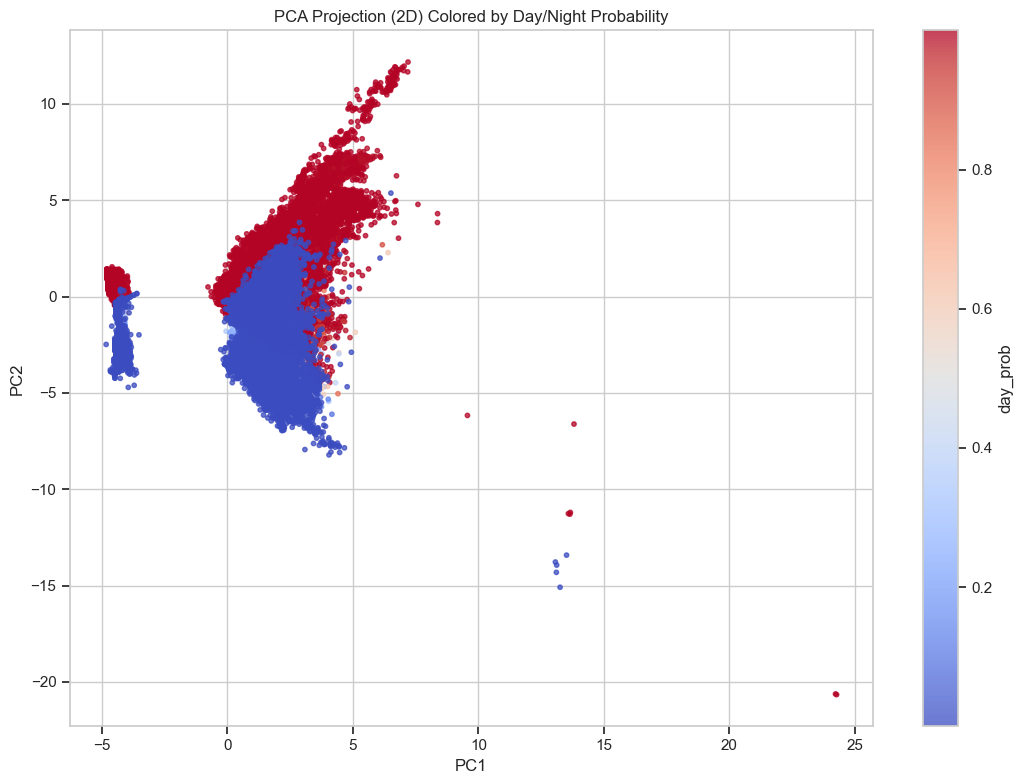

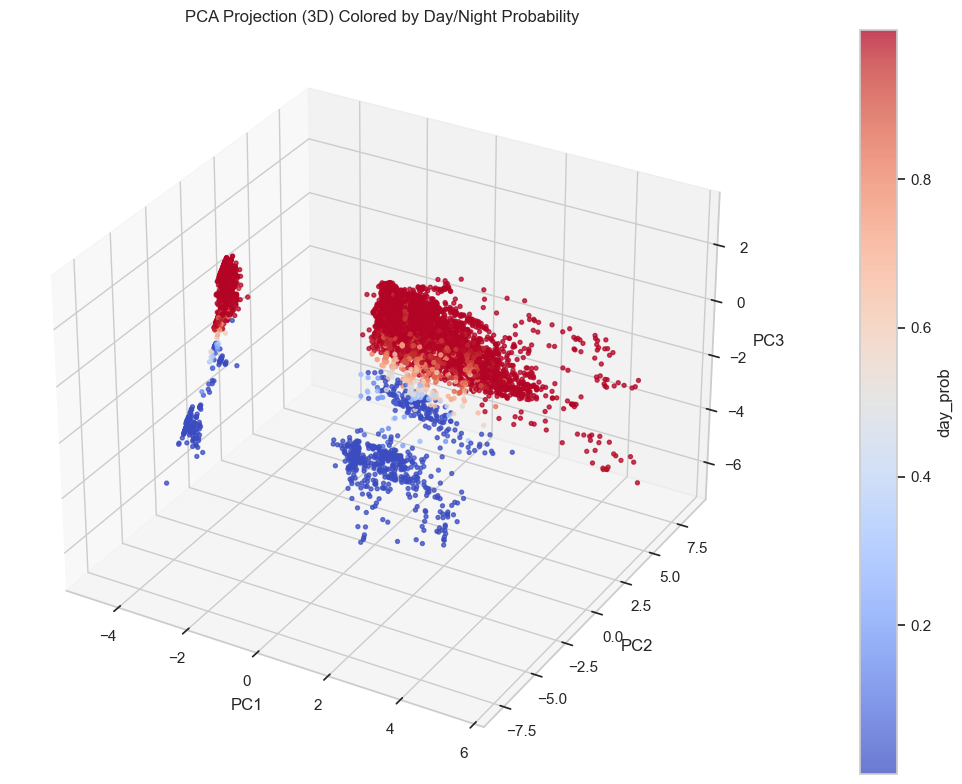

Isolated group rule: PC1 < -2 and PC2 > -5
Group size: 60,609 / 230,400 (26.31%)
Mean day_prob in isolated group: 0.8801
Mean day_prob in rest:           0.8230


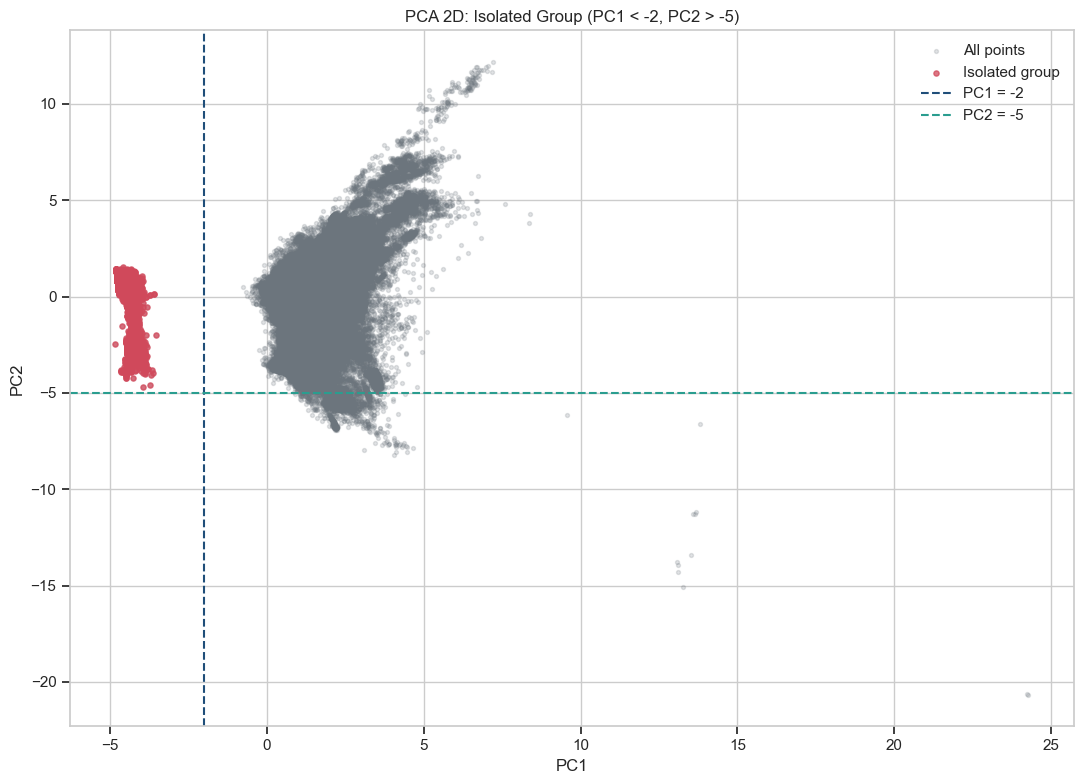


Top towns in isolated group:
scenario
TOWN04    19090
TOWN03    12816
TOWN01     8601
TOWN05     8087
TOWN02     6297
TOWN10     5718
Name: count, dtype: int64

Top scenarios in isolated group:
scenario
14D_HardRainSunset_Town04_LowVol                2538
02D_CloudyNoon_Town04_LowVol                    2432
05D_SoftRainNoon_Town04_LowVol                  2389
11D_WetCloudySunset_Town04_LowVol               2242
08D_ClearSunset_Town04_LowVol                   2170
14C_HardRainSunset_Town04_HighVol               2126
15D_HardRainNoon_Town10HD_LowVol_NoFog_Night    1984
11B_WetCloudySunset_Town03_LowVol               1796
08B_ClearSunset_Town03_LowVol                   1635
02B_CloudyNoon_Town03_LowVol                    1618
Name: count, dtype: int64


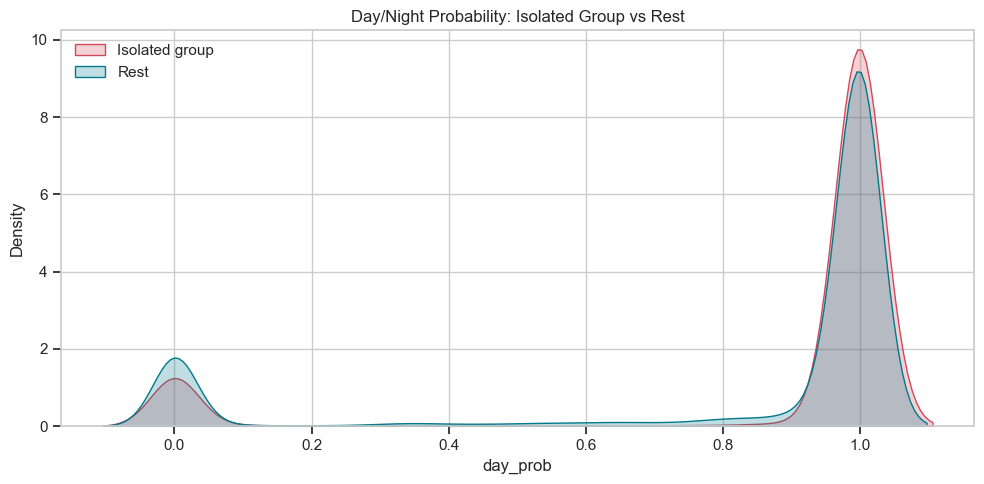

In [18]:
# PCA diagnostics colored by day/night probability + custom group breakdown

day_prob_series = pd.to_numeric(df.loc[valid_target, "day_prob"], errors="coerce")
if day_prob_series.notna().any():
    day_prob_plot = day_prob_series.fillna(day_prob_series.median())
else:
    day_prob_plot = pd.Series(np.zeros(len(day_prob_series)), index=day_prob_series.index)

# 2D PCA colored by day/night probability
plt.figure(figsize=(11, 8))
sc_day = plt.scatter(
    X_pca2[:, 0],
    X_pca2[:, 1],
    c=day_prob_plot.values,
    cmap="coolwarm",
    s=10,
    alpha=0.75,
)
plt.colorbar(sc_day, label="day_prob")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection (2D) Colored by Day/Night Probability")
plt.tight_layout()
plt.show()

# 3D PCA colored by day/night probability (same sample as previous 3D plot)
fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection="3d")
pts_day = ax.scatter(
    X_pca3[idx, 0],
    X_pca3[idx, 1],
    X_pca3[idx, 2],
    c=day_prob_plot.values[idx],
    cmap="coolwarm",
    s=8,
    alpha=0.75,
)
fig.colorbar(pts_day, ax=ax, pad=0.1, label="day_prob")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("PCA Projection (3D) Colored by Day/Night Probability")
plt.tight_layout()
plt.show()

# Custom group diagnostics: isolate with PC1 < -2 and PC2 > -5
left_mask = (X_pca2[:, 0] < -2.0) & (X_pca2[:, 1] > -5.0)

town_series = pd.Series(town_labels).reset_index(drop=True)
scenario_series = pd.Series(scenario_for_pca).reset_index(drop=True)

left_day_mean = float(np.nanmean(day_prob_plot.values[left_mask])) if np.any(left_mask) else float("nan")
rest_day_mean = float(np.nanmean(day_prob_plot.values[~left_mask])) if np.any(~left_mask) else float("nan")

print("Isolated group rule: PC1 < -2 and PC2 > -5")
print(f"Group size: {int(left_mask.sum()):,} / {len(left_mask):,} ({100.0 * left_mask.mean():.2f}%)")
print(f"Mean day_prob in isolated group: {left_day_mean:.4f}")
print(f"Mean day_prob in rest:           {rest_day_mean:.4f}")

# Visual sanity check of the exact region and selected points
plt.figure(figsize=(11, 8))
plt.scatter(X_pca2[:, 0], X_pca2[:, 1], s=8, alpha=0.20, color="#6c757d", label="All points")
if np.any(left_mask):
    plt.scatter(
        X_pca2[left_mask, 0],
        X_pca2[left_mask, 1],
        s=14,
        alpha=0.75,
        color="#d1495b",
        label="Isolated group",
    )
plt.axvline(-2.0, color="#1f4e79", linestyle="--", linewidth=1.5, label="PC1 = -2")
plt.axhline(-5.0, color="#2a9d8f", linestyle="--", linewidth=1.5, label="PC2 = -5")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA 2D: Isolated Group (PC1 < -2, PC2 > -5)")
plt.legend(loc="best")
plt.tight_layout()
plt.show()

print("\nTop towns in isolated group:")
print(town_series[left_mask].value_counts().head(10))

print("\nTop scenarios in isolated group:")
print(scenario_series[left_mask].value_counts().head(10))

if np.any(left_mask) and np.any(~left_mask):
    plt.figure(figsize=(10, 5))
    sns.kdeplot(day_prob_plot.values[left_mask], fill=True, label="Isolated group", color="#d1495b")
    sns.kdeplot(day_prob_plot.values[~left_mask], fill=True, label="Rest", color="#00798c")
    plt.xlabel("day_prob")
    plt.title("Day/Night Probability: Isolated Group vs Rest")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("\nSkipping KDE comparison because one of the groups is empty.")

## Isolated Group Characterization
Detailed profiling of the isolated PCA region defined by PC1 < -2 and PC2 > -5.

Isolated rule: PC1 < -2 and PC2 > -5
Rows in isolated group: 60,609 / 230,400 (26.31%)

Metric comparison (isolated vs rest):


,isolated_mean,rest_mean,delta
ground_truth_risk,3.577608,3.118478,0.459130
true_ego_speed,10.217226,3.017486,7.199740
day_prob,0.880062,0.823024,0.057038



Top 12 strongest feature differences (by |z_diff|):


,isolated_mean,rest_mean,delta,z_diff,abs_z_diff
depth_min_norm,1.000000,0.008792,0.991208,2.270935,2.270935
size_change_avg,0.000000,1.009716,-1.009716,-2.259892,2.259892
depth_change_avg,0.000000,1.007745,-1.007745,-2.257217,2.257217
size_change_max,0.000000,1.035256,-1.035256,-2.248523,2.248523
depth_change_max,0.000000,1.032569,-1.032569,-2.241844,2.241844
depth_avg_norm,0.000000,0.012778,-0.012778,-1.381500,1.381500
num_objects,0.059232,3.014159,-2.954926,-1.369846,1.369846
bb_size_avg,0.000000,0.082877,-0.082877,-1.309089,1.309089
bb_size_max,0.000000,0.123386,-0.123386,-1.270949,1.270949
center_threat_avg,0.000000,1.077936,-1.077936,-0.878431,0.878431



Top towns in isolated group:
town
TOWN04    19090
TOWN03    12816
TOWN01     8601
TOWN05     8087
TOWN02     6297
TOWN10     5718
Name: count, dtype: int64

Top scenarios in isolated group:
scenario
14D_HardRainSunset_Town04_LowVol                2538
02D_CloudyNoon_Town04_LowVol                    2432
05D_SoftRainNoon_Town04_LowVol                  2389
11D_WetCloudySunset_Town04_LowVol               2242
08D_ClearSunset_Town04_LowVol                   2170
14C_HardRainSunset_Town04_HighVol               2126
15D_HardRainNoon_Town10HD_LowVol_NoFog_Night    1984
11B_WetCloudySunset_Town03_LowVol               1796
08B_ClearSunset_Town03_LowVol                   1635
02B_CloudyNoon_Town03_LowVol                    1618
05B_SoftRainNoon_Town03_LowVol                  1594
11C_WetCloudySunset_Town04_HighVol              1539
Name: count, dtype: int64

Top weather labels in isolated group:
weather_str
HardRainSunset     7424
ClearSunset        6399
SoftRainNoon       6372
WetCloudySunset

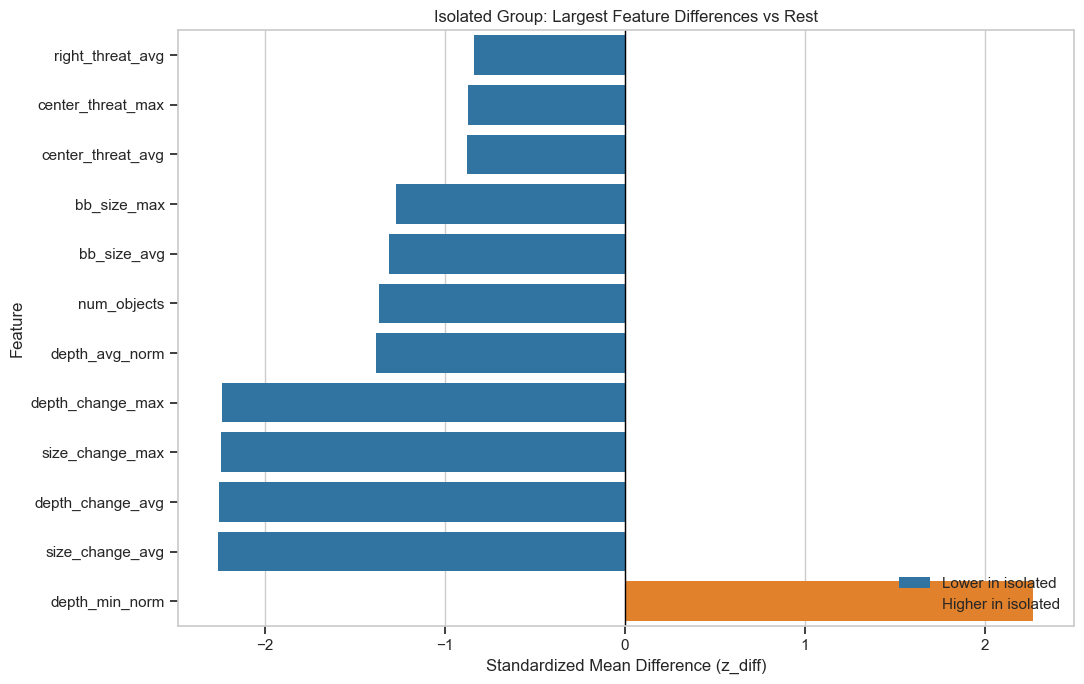

In [21]:
# Characterize isolated group from the previous diagnostic rule
iso_mask = (X_pca2[:, 0] < -2.0) & (X_pca2[:, 1] > -5.0)

base_cols = ["scenario", "ground_truth_risk", "true_ego_speed", "day_prob", "weather"]
sel_cols = list(dict.fromkeys(base_cols + feature_cols))

iso_df = df.loc[valid_target, sel_cols].copy().reset_index(drop=True)

iso_df["town"] = (
    iso_df["scenario"]
    .astype(str)
    .str.extract(r"(Town\d+)", expand=False)
    .str.upper()
    .fillna("UNKNOWN")
)
iso_df["weather_str"] = iso_df["weather"].astype(str)

iso_size = int(iso_mask.sum())
all_size = len(iso_mask)
print(f"Isolated rule: PC1 < -2 and PC2 > -5")
print(f"Rows in isolated group: {iso_size:,} / {all_size:,} ({100.0 * iso_size / all_size:.2f}%)")

# Core metric comparison against the rest
metrics = ["ground_truth_risk", "true_ego_speed", "day_prob"]
metric_cmp = pd.DataFrame({
    "isolated_mean": iso_df.loc[iso_mask, metrics].mean(numeric_only=True),
    "rest_mean": iso_df.loc[~iso_mask, metrics].mean(numeric_only=True),
})
metric_cmp["delta"] = metric_cmp["isolated_mean"] - metric_cmp["rest_mean"]
print("\nMetric comparison (isolated vs rest):")
display(metric_cmp)

# Biggest feature differences (standardized mean difference)
feature_mean_iso = iso_df.loc[iso_mask, feature_cols].mean(numeric_only=True)
feature_mean_rest = iso_df.loc[~iso_mask, feature_cols].mean(numeric_only=True)
feature_std_all = iso_df[feature_cols].std(numeric_only=True).replace(0, np.nan)

feature_diff = pd.DataFrame({
    "isolated_mean": feature_mean_iso,
    "rest_mean": feature_mean_rest,
})
feature_diff["delta"] = feature_diff["isolated_mean"] - feature_diff["rest_mean"]
feature_diff["z_diff"] = (feature_diff["delta"] / feature_std_all).fillna(0.0)
feature_diff["abs_z_diff"] = feature_diff["z_diff"].abs()
feature_diff = feature_diff.sort_values("abs_z_diff", ascending=False)

print("\nTop 12 strongest feature differences (by |z_diff|):")
display(feature_diff.head(12))

# Composition summaries
print("\nTop towns in isolated group:")
print(iso_df.loc[iso_mask, "town"].value_counts().head(10))

print("\nTop scenarios in isolated group:")
print(iso_df.loc[iso_mask, "scenario"].value_counts().head(12))

print("\nTop weather labels in isolated group:")
print(iso_df.loc[iso_mask, "weather_str"].value_counts().head(10))

# Visual: strongest differences in the isolated group
plot_diff = feature_diff.head(12).iloc[::-1].copy()
plot_diff["direction"] = np.where(plot_diff["z_diff"] >= 0, "Higher in isolated", "Lower in isolated")

plt.figure(figsize=(11, 7))
sns.barplot(data=plot_diff, x="z_diff", y=plot_diff.index, hue="direction", dodge=False)
plt.axvline(0.0, color="black", linewidth=1)
plt.xlabel("Standardized Mean Difference (z_diff)")
plt.ylabel("Feature")
plt.title("Isolated Group: Largest Feature Differences vs Rest")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## Clustering Analysis (n Clusters)
Clustering on standardized feature vectors, with per-cluster characterization and strongest distinguishing features.

Running clustering with n_clusters = 6

Cluster sizes:


,rows,pct
cluster,,
0,60609,26.31
1,49292,21.39
2,37780,16.40
3,3017,1.31
4,29898,12.98
5,49804,21.62



Cluster mean metrics:


,ground_truth_risk,true_ego_speed,day_prob
cluster,,,
0,3.577608,10.217226,0.880062
1,2.901838,2.551828,0.521531
2,2.497827,2.949567,0.867607
3,2.719905,1.751044,0.983209
4,2.504240,0.826316,0.963893
5,4.196580,4.921985,0.993330



Top distinguishing features in each cluster (largest |z_diff|):


,cluster,feature,z_diff,abs_z_diff
0,0,depth_min_norm,1.673543,1.673543
1,0,size_change_avg,-1.665405,1.665405
2,0,depth_change_avg,-1.663434,1.663434
3,0,size_change_max,-1.657027,1.657027
4,0,depth_change_max,-1.652105,1.652105
5,0,depth_avg_norm,-1.018083,1.018083
6,0,num_objects,-1.009495,1.009495
7,0,bb_size_avg,-0.964720,0.964720
8,1,bb_size_avg,1.008572,1.008572
9,1,day_prob,-0.909389,0.909389



Top towns per cluster (% share):


,cluster,town,pct
0,0,TOWN04,31.496972
1,0,TOWN03,21.145374
2,0,TOWN01,14.190962
6,1,TOWN10,33.611945
7,1,TOWN02,24.997971
8,1,TOWN01,24.677432
12,2,TOWN03,26.206988
13,2,TOWN05,17.800424
14,2,TOWN02,17.112229
18,3,TOWN03,65.528671



Top scenarios per cluster (% share):


,cluster,scenario,pct
0,0,14D_HardRainSunset_Town04_LowVol,4.187497
1,0,02D_CloudyNoon_Town04_LowVol,4.012605
2,0,05D_SoftRainNoon_Town04_LowVol,3.941659
64,1,15C_WetNoon_Town10HD_HighVol_NoFog_Night,6.554816
65,1,16C_SoftRainSunset_Town02_HighVol_Fog_Night,6.392518
66,1,12C_SoftRainSunset_Town10HD_HighVol,6.248478
126,2,01A_ClearNoon_Town01_HighVol,7.104288
127,2,01B_ClearNoon_Town01_LowVol,6.836951
128,2,15A_ClearNoon_Town05_HighVol_NoFog_Night,6.741662
187,3,14B_HardRainSunset_Town03_LowVol,32.979781


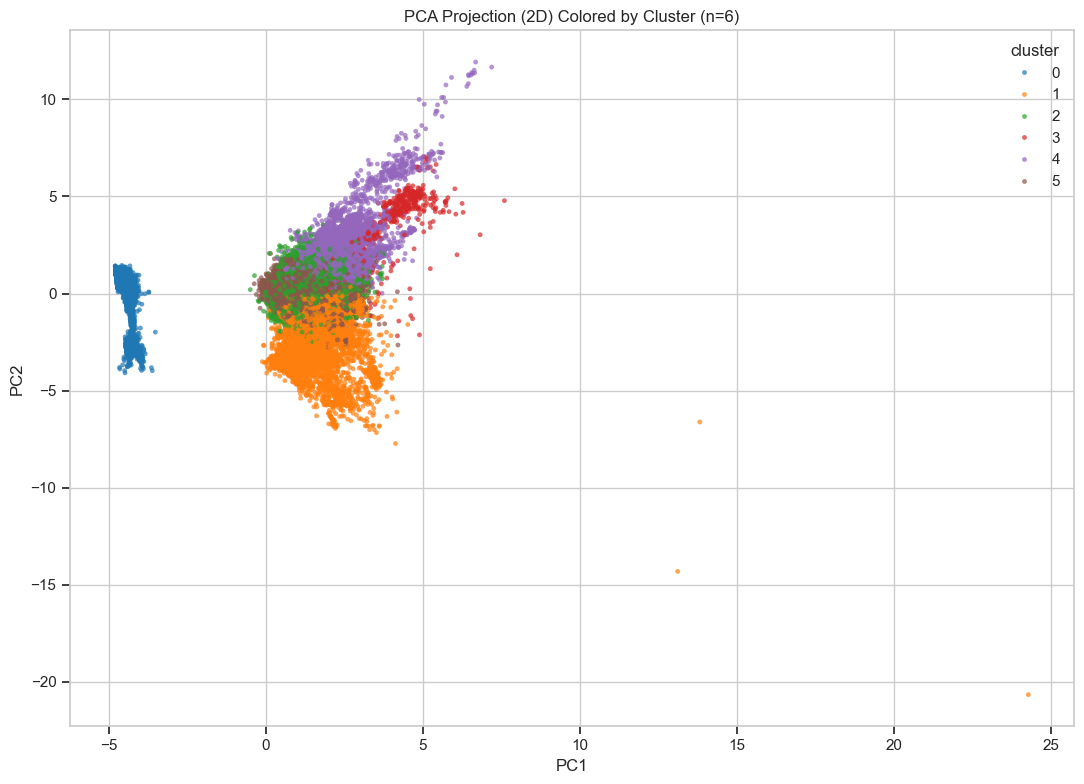

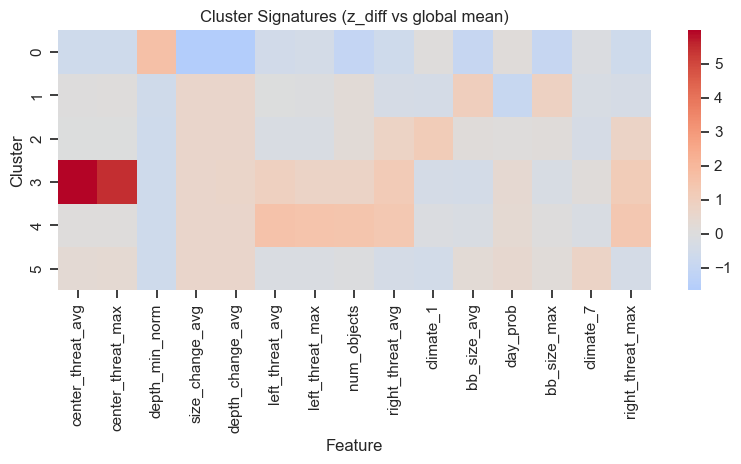

In [22]:
# Cluster the data and characterize each cluster
from sklearn.cluster import MiniBatchKMeans

n_clusters = 6  # Change this to any n you want
print(f"Running clustering with n_clusters = {n_clusters}")

# Reuse PCA-prepared matrix when available; otherwise rebuild quickly
if "X_scaled" not in globals():
    X_tmp = df.loc[valid_target, feature_cols].copy()
    imputer_tmp = SimpleImputer(strategy="median")
    scaler_tmp = StandardScaler()
    X_scaled_local = scaler_tmp.fit_transform(imputer_tmp.fit_transform(X_tmp))
else:
    X_scaled_local = X_scaled

cluster_model = MiniBatchKMeans(
    n_clusters=n_clusters,
    random_state=42,
    batch_size=4096,
    n_init=10,
)
cluster_labels = cluster_model.fit_predict(X_scaled_local)

base_cols = ["scenario", "ground_truth_risk", "true_ego_speed", "day_prob", "weather"]
sel_cols = list(dict.fromkeys(base_cols + feature_cols))

cluster_df = df.loc[valid_target, sel_cols].copy().reset_index(drop=True)
cluster_df["cluster"] = cluster_labels
cluster_df["town"] = (
    cluster_df["scenario"]
    .astype(str)
    .str.extract(r"(Town\d+)", expand=False)
    .str.upper()
    .fillna("UNKNOWN")
)
cluster_df["weather_str"] = cluster_df["weather"].astype(str)

# Cluster sizes
cluster_sizes = cluster_df["cluster"].value_counts().sort_index().rename("rows").to_frame()
cluster_sizes["pct"] = (100.0 * cluster_sizes["rows"] / len(cluster_df)).round(2)
print("\nCluster sizes:")
display(cluster_sizes)

# Core metric characterization
cluster_metrics = cluster_df.groupby("cluster")[["ground_truth_risk", "true_ego_speed", "day_prob"]].mean(numeric_only=True)
print("\nCluster mean metrics:")
display(cluster_metrics)

# Biggest differences for each cluster (vs global mean) using z-diff
global_mean = cluster_df[feature_cols].mean(numeric_only=True)
global_std = cluster_df[feature_cols].std(numeric_only=True).replace(0, np.nan)

rows = []
for c in sorted(cluster_df["cluster"].unique()):
    c_mean = cluster_df.loc[cluster_df["cluster"] == c, feature_cols].mean(numeric_only=True)
    z_diff = ((c_mean - global_mean) / global_std).fillna(0.0)
    top = z_diff.abs().sort_values(ascending=False).head(8).index
    for feat in top:
        rows.append({
            "cluster": int(c),
            "feature": feat,
            "z_diff": float(z_diff[feat]),
            "abs_z_diff": float(abs(z_diff[feat])),
        })

cluster_diff = pd.DataFrame(rows).sort_values(["cluster", "abs_z_diff"], ascending=[True, False])
print("\nTop distinguishing features in each cluster (largest |z_diff|):")
display(cluster_diff)

# Per-cluster dominant town and scenario
town_top = (
    cluster_df.groupby("cluster")["town"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("pct")
    .reset_index()
    .sort_values(["cluster", "pct"], ascending=[True, False])
    .groupby("cluster")
    .head(3)
)
print("\nTop towns per cluster (% share):")
display(town_top)

scenario_top = (
    cluster_df.groupby("cluster")["scenario"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("pct")
    .reset_index()
    .sort_values(["cluster", "pct"], ascending=[True, False])
    .groupby("cluster")
    .head(3)
)
print("\nTop scenarios per cluster (% share):")
display(scenario_top)

# 2D PCA view colored by cluster
plot_cluster = pd.DataFrame({
    "PC1": X_pca2[:, 0],
    "PC2": X_pca2[:, 1],
    "cluster": cluster_labels,
})

max_plot_points = 50000
if len(plot_cluster) > max_plot_points:
    plot_cluster = plot_cluster.sample(max_plot_points, random_state=42)

plt.figure(figsize=(11, 8))
sns.scatterplot(
    data=plot_cluster,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="tab10",
    s=12,
    alpha=0.70,
    linewidth=0,
)
plt.title(f"PCA Projection (2D) Colored by Cluster (n={n_clusters})")
plt.tight_layout()
plt.show()

# Heatmap of strongest cluster differences
heat_features = (
    cluster_diff.sort_values("abs_z_diff", ascending=False)
    .groupby("cluster")
    .head(3)["feature"]
    .drop_duplicates()
    .tolist()
)

heat_data = []
for c in sorted(cluster_df["cluster"].unique()):
    c_mean = cluster_df.loc[cluster_df["cluster"] == c, feature_cols].mean(numeric_only=True)
    z_diff = ((c_mean - global_mean) / global_std).fillna(0.0)
    heat_data.append(z_diff.loc[heat_features].rename(c))

heat_df = pd.DataFrame(heat_data)

plt.figure(figsize=(max(8, 0.55 * len(heat_features)), 4.8))
sns.heatmap(heat_df, cmap="coolwarm", center=0.0, annot=False)
plt.title("Cluster Signatures (z_diff vs global mean)")
plt.xlabel("Feature")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()